# AICE Associate 대비 실습 과정 — 4회차 예제 1
## 캘리포니아 주택 가격 데이터 전처리 (수치형 중심, 회귀)

> **선수 학습**: `04_데이터전처리하기.ipynb` 에서 배운 결측·이상치·구간화·인코딩·분할·스케일링 개념  
> **데이터**: `data/california_housing_train.csv` (17,000행), `data/california_housing_test.csv` (3,000행)  
> **목표 변수**: `주택가격` (구역별 주택 가격 중앙값, 달러) → **회귀** 문제

### 이 예제의 흐름

```
① 데이터 불러오기 → ② 전처리를 위한 EDA (무엇을 고칠지 찾기)
→ ③ 결측치 랜덤 생성 (실습용 데이터셋 만들기)
→ ④ 결측치 처리 (방법별 정확도 비교) → ⑤ 파생 변수 → ⑥ 이상치 처리 → ⑦ 구간화·인코딩
→ ⑧ 분할 (stratify) → ⑨ 스케일링 → ⑩ 전처리 전후 모델 성능 비교 → ⑪ 저장 → 실습 문제
```

> 이 데이터는 원래 **결측치가 없고 수치형만** 있습니다. 실무 데이터처럼 만들기 위해 ③ 에서 결측을 일부러 만들고, 그 덕분에 **진짜 값을 알고 있는 상태에서** 어떤 대체 방법이 가장 정확한지 직접 채점해 볼 수 있습니다.

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = "data"

In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# 원본 컬럼명은 영어라서 읽은 뒤 한글로 바꾼다
HOUSING_COLS = {
  "longitude": "경도",                 # 서쪽일수록 작은 값 (-124 ~ -114)
  "latitude": "위도",                  # 북쪽일수록 큰 값 (32 ~ 42)
  "housing_median_age": "주택연식",    # 구역 주택 나이의 중앙값 (년)
  "total_rooms": "총방수",             # 구역 내 전체 방 수
  "total_bedrooms": "총침실수",        # 구역 내 전체 침실 수
  "population": "인구",                # 구역 인구
  "households": "가구수",              # 구역 가구 수
  "median_income": "소득중앙값",       # 가구 소득 중앙값 (단위: 만 달러)
  "median_house_value": "주택가격",    # 구역 주택 가격 중앙값 (달러) <- 목표 변수
}

for name in ["california_housing_train.csv", "california_housing_test.csv"]:
  if not os.path.exists(f"{DATA_DIR}/{name}"):
    raise FileNotFoundError(f"{DATA_DIR}/{name} 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
housing_test = pd.read_csv(f"{DATA_DIR}/california_housing_test.csv").rename(columns=HOUSING_COLS)
print("train:", housing.shape, "| test:", housing_test.shape)
housing.head()

train: (17000, 9) | test: (3000, 9)


,경도,위도,주택연식,총방수,총침실수,인구,가구수,소득중앙값,주택가격
0,-114.31,34.19,15.00,"5,612.00","1,283.00","1,015.00",472.00,1.49,"66,900.00"
1,-114.47,34.40,19.00,"7,650.00","1,901.00","1,129.00",463.00,1.82,"80,100.00"
2,-114.56,33.69,17.00,720.00,174.00,333.00,117.00,1.65,"85,700.00"
3,-114.57,33.64,14.00,"1,501.00",337.00,515.00,226.00,3.19,"73,400.00"
4,-114.57,33.57,20.00,"1,454.00",326.00,624.00,262.00,1.93,"65,500.00"


---
## 1. 전처리를 위한 탐색적 데이터 분석 (EDA)

3회차 EDA 가 "데이터를 이해" 하는 것이었다면, 여기서는 **"무엇을 고쳐야 하는가"** 를 찾는 데 집중합니다. 다섯 가지 질문을 차례로 던집니다.

| 질문 | 확인 방법 | 찾으면 하는 전처리 |
|------|------|------|
| ① 타입과 결측은? | `info()`, `isnull().sum()` | 결측 대체, 타입 변환 |
| ② 분포가 치우쳤나? | `skew()`, 히스토그램 | 로그 변환 |
| ③ 극단값이 있나? | 박스플롯, IQR | 이상치 clip / 제거 |
| ④ 이상하게 잘린 값이 있나? | 최댓값 빈도, 히스토그램 끝 | 상한값 행 처리 |
| ⑤ 변수끼리 너무 비슷한가? | 상관 히트맵 | 파생 변수(비율)로 대체 |

### 1.1 타입과 결측

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   경도      17000 non-null  float64
 1   위도      17000 non-null  float64
 2   주택연식    17000 non-null  float64
 3   총방수     17000 non-null  float64
 4   총침실수    17000 non-null  float64
 5   인구      17000 non-null  float64
 6   가구수     17000 non-null  float64
 7   소득중앙값   17000 non-null  float64
 8   주택가격    17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
print("결측치 합계:", housing.isnull().sum().sum(), "-> 원본에는 결측이 없다. 3장에서 실습용으로 만든다.")
print("문자열 컬럼:", housing.select_dtypes("object").columns.tolist(), "-> 범주형이 없다. 7장에서 구간화로 만든다.")

결측치 합계: 0 -> 원본에는 결측이 없다. 3장에서 실습용으로 만든다.
문자열 컬럼: [] -> 범주형이 없다. 7장에서 구간화로 만든다.


### 1.2 분포의 치우침

In [6]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
경도,"17,000.00",-119.56,2.01,-124.35,-121.79,-118.49,-118.00,-114.31
위도,"17,000.00",35.63,2.14,32.54,33.93,34.25,37.72,41.95
주택연식,"17,000.00",28.59,12.59,1.00,18.00,29.00,37.00,52.00
총방수,"17,000.00","2,643.66","2,179.95",2.00,"1,462.00","2,127.00","3,151.25","37,937.00"
총침실수,"17,000.00",539.41,421.50,1.00,297.00,434.00,648.25,"6,445.00"
인구,"17,000.00","1,429.57","1,147.85",3.00,790.00,"1,167.00","1,721.00","35,682.00"
가구수,"17,000.00",501.22,384.52,1.00,282.00,409.00,605.25,"6,082.00"
소득중앙값,"17,000.00",3.88,1.91,0.50,2.57,3.54,4.77,15.00
주택가격,"17,000.00","207,300.91","115,983.76","14,999.00","119,400.00","180,400.00","265,000.00","500,001.00"


In [7]:
skew = housing.skew().sort_values(ascending=False)
print(skew.round(2))
print("\n|왜도| > 1 인 컬럼:", skew[skew.abs() > 1].index.tolist())

인구       5.19
총방수      4.00
가구수      3.34
총침실수     3.32
소득중앙값    1.63
주택가격     0.97
위도       0.47
주택연식     0.06
경도      -0.30
dtype: float64

|왜도| > 1 인 컬럼: ['인구', '총방수', '가구수', '총침실수', '소득중앙값']


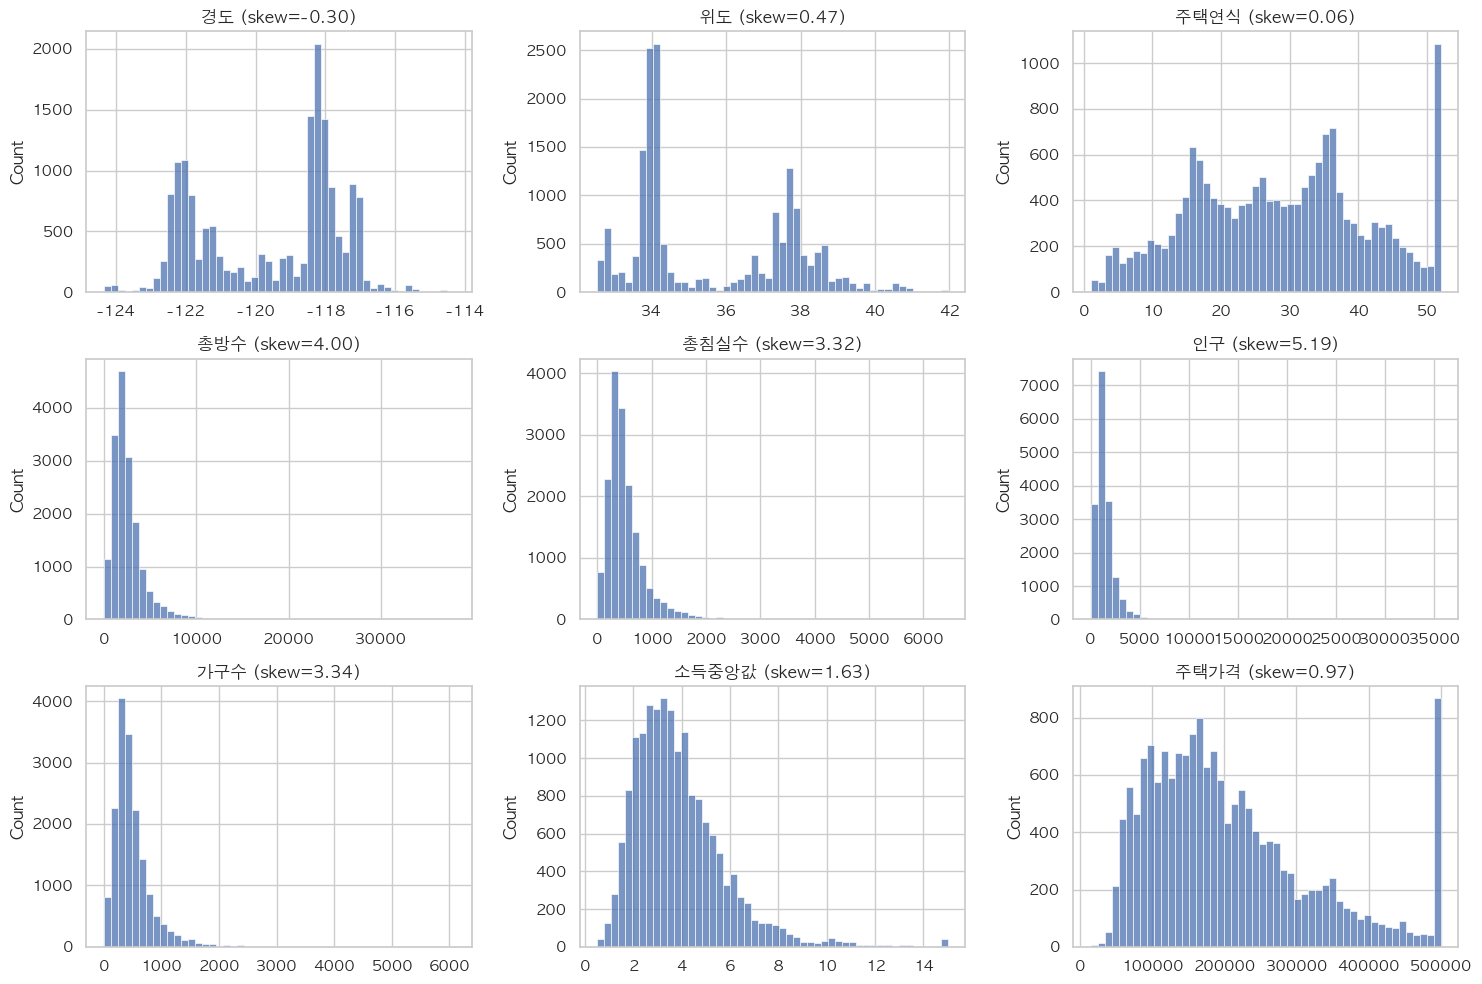

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), housing.columns):
  sns.histplot(housing[col], bins=50, ax=ax)
  ax.set_title(f"{col} (skew={housing[col].skew():.2f})")
  ax.set_xlabel("")
plt.tight_layout()
plt.show()

**읽을 것**

- `총방수`, `총침실수`, `인구`, `가구수` 는 왜도 3~5 로 **오른쪽 꼬리가 매우 길다.** 대부분 구역은 작고 소수의 거대 구역이 있다는 뜻입니다. → 로그 변환 또는 비율 파생 변수
- `주택가격` 오른쪽 끝, `주택연식` 오른쪽 끝에 **뾰족한 막대** 가 있습니다. → 1.4 에서 확인

### 1.3 극단값 (박스플롯)

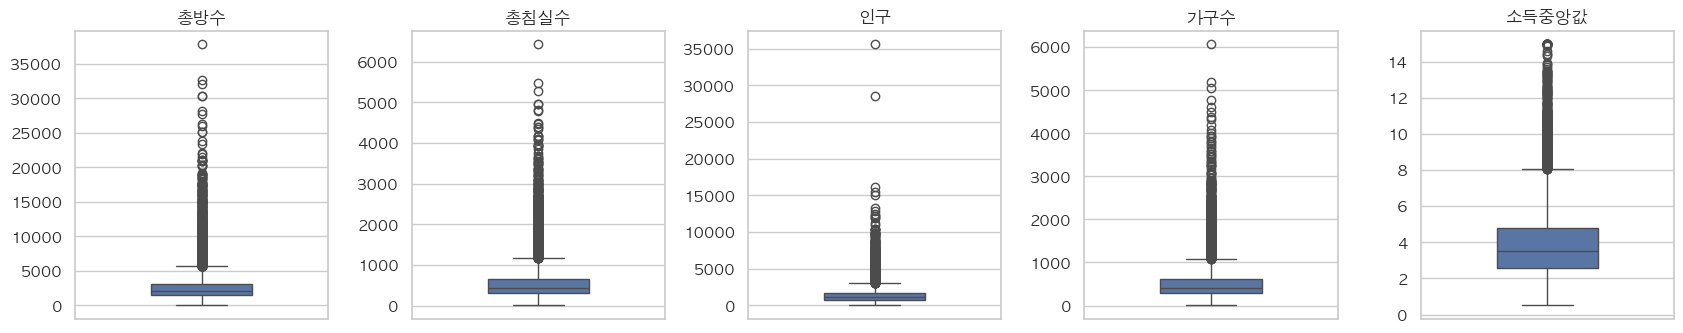

In [9]:
cols = ["총방수", "총침실수", "인구", "가구수", "소득중앙값"]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
for ax, col in zip(axes, cols):
  sns.boxplot(y=housing[col], ax=ax, width=0.4)
  ax.set_title(col)
  ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [10]:
def iqr_outlier_count(s: pd.Series, k: float = 1.5) -> int:
  q1, q3 = s.quantile([0.25, 0.75])
  iqr = q3 - q1
  return int(((s < q1 - k * iqr) | (s > q3 + k * iqr)).sum())


outlier_table = pd.DataFrame({
  "IQR 이상치 수": {c: iqr_outlier_count(housing[c]) for c in housing.columns},
  "비율(%)": {c: round(iqr_outlier_count(housing[c]) / len(housing) * 100, 1) for c in housing.columns},
})
outlier_table.sort_values("IQR 이상치 수", ascending=False)

,IQR 이상치 수,비율(%)
총방수,1076,6.30
총침실수,1074,6.30
가구수,1032,6.10
인구,1015,6.00
주택가격,895,5.30
소득중앙값,563,3.30
경도,0,0.00
위도,0,0.00
주택연식,0,0.00


이상치 비율이 5~6% 에 이르는 컬럼이 있습니다. 이 정도면 **IQR 기준으로 전부 지우면 데이터 손실이 큽니다.** 치우친 분포에서는 IQR 이 "정상적인 큰 값" 까지 이상치로 잡기 때문입니다. → 6장에서 **분위수 clip** 과 **로그 변환** 을 사용합니다.

### 1.4 상한으로 잘린 값 (capping)

In [11]:
for col in ["주택가격", "주택연식", "소득중앙값"]:
  mx = housing[col].max()
  n_max = (housing[col] == mx).sum()
  print(f"{col:<6}: 최댓값 {mx:>10,.1f} 이 {n_max:>5}번 등장 ({n_max / len(housing):.1%})")

주택가격  : 최댓값  500,001.0 이   814번 등장 (4.8%)
주택연식  : 최댓값       52.0 이  1052번 등장 (6.2%)
소득중앙값 : 최댓값       15.0 이    38번 등장 (0.2%)


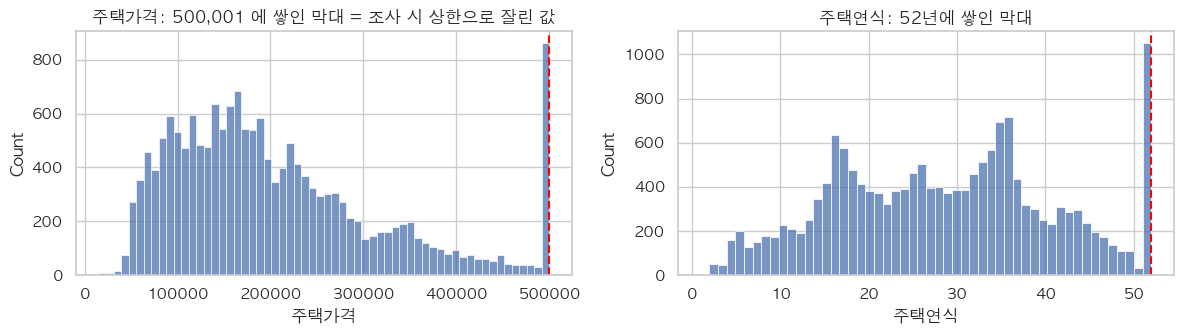

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(housing["주택가격"], bins=60, ax=axes[0])
axes[0].axvline(500001, color="red", linestyle="--")
axes[0].set_title("주택가격: 500,001 에 쌓인 막대 = 조사 시 상한으로 잘린 값")
sns.histplot(housing["주택연식"], bins=52, ax=axes[1])
axes[1].axvline(52, color="red", linestyle="--")
axes[1].set_title("주택연식: 52년에 쌓인 막대")
plt.tight_layout()
plt.show()

`주택가격 = 500,001` 인 구역은 실제 가격이 그보다 **훨씬 비쌀 수 있지만 기록이 잘린 것** 입니다. 모델이 이 값을 그대로 배우면 "비싼 구역의 가격은 50만 달러" 라고 잘못 학습합니다. **목표 변수의 상한 행은 제거** 하는 것이 일반적입니다. (`주택연식` 52 는 입력 변수라 영향이 작아 그대로 둡니다.)

### 1.5 변수 간 상관 (다중공선성)

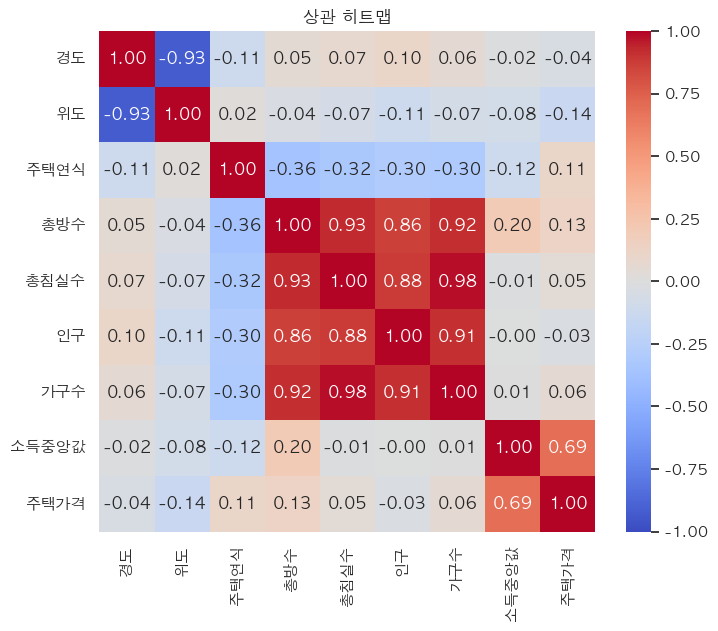

In [13]:
corr = housing.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("상관 히트맵")
plt.show()

**읽을 것**

- `총방수`, `총침실수`, `인구`, `가구수` 끼리 상관이 **0.86 ~ 0.98**. 모두 "구역이 얼마나 큰가" 를 말하는 같은 정보입니다. 선형 모델에서 이런 **다중공선성** 은 계수를 불안정하게 만듭니다. → 5장에서 **가구당방수, 침실비율, 가구당인구** 같은 비율로 바꿉니다.
- 목표 변수와는 `소득중앙값` 이 가장 강하게 연관(0.69). → 7장에서 `소득중앙값` 구간으로 **층화 분할** 합니다.

### 1.6 위치 정보

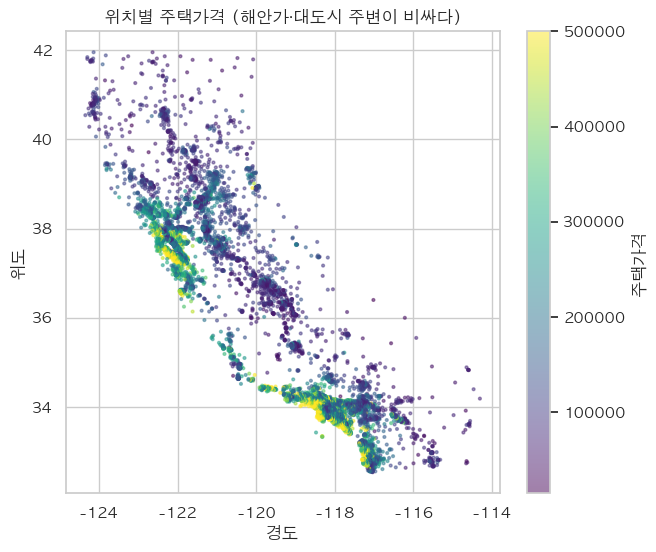

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(housing["경도"], housing["위도"], c=housing["주택가격"], cmap="viridis", s=4, alpha=0.5)
plt.colorbar(sc, ax=ax, label="주택가격")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("위치별 주택가격 (해안가·대도시 주변이 비싸다)")
plt.show()

`경도`, `위도` 는 숫자지만 **값의 크기 자체보다 "어느 지역이냐"** 가 중요합니다. → 7장에서 위도를 **권역(남부·중부·북부)** 이라는 범주형으로 만들어 인코딩을 실습합니다.

### 1.7 EDA 결론: 전처리 계획표

| 발견 | 전처리 | 장 |
|------|------|:---:|
| 결측 없음 (실무에선 흔함) | 결측을 만들어 대체 방법 비교 | 3, 4 |
| 크기 변수 4개가 서로 상관 0.9 이상, 왜도 3~5 | 비율 파생 변수, 로그 변환 | 5, 6 |
| IQR 이상치 비율 5% 이상 | 분위수 clip | 6 |
| 주택가격 500,001 상한 | 상한 행 제거 | 6 |
| 위치 정보 | 위도로 권역 범주 생성 → 원-핫 | 7 |
| 소득중앙값이 가장 중요 | 소득 구간으로 층화 분할 | 7, 8 |
| 컬럼마다 단위가 다름 | StandardScaler | 9 |

---
## 2. 실습용 데이터셋 만들기: 결측치 랜덤 생성

**전처리 직전** 에, 수치형 컬럼 일부에 무작위로 결측을 심습니다. 원본은 `housing_true` 로 보관해 두었다가 4장에서 **대체 결과를 채점** 하는 데 씁니다.

| 컬럼 | 결측 비율 | 의도 |
|------|:---:|------|
| `총침실수` | 5% | 다른 컬럼(총방수)과 관계가 강해 **관계 기반 대체** 가 가능 |
| `주택연식` | 3% | 대칭에 가까운 분포 → 평균·중앙값 차이 작음 |
| `소득중앙값` | 2% | 치우친 분포·가장 중요한 변수 → 대체 방법이 성능에 영향 |
| `인구` | 4% | 왜도가 매우 큼 → 평균 대체가 위험 |

In [15]:
def make_missing(df: pd.DataFrame, ratios: dict[str, float], seed: int = 42) -> pd.DataFrame:
  '''컬럼별 비율만큼 무작위 행을 골라 NaN 으로 바꾼 복사본을 돌려준다.'''
  rng = np.random.default_rng(seed)
  out = df.copy()
  for col, ratio in ratios.items():
    n_missing = int(len(out) * ratio)
    rows = rng.choice(out.index, size=n_missing, replace=False)   # 비복원 추출: 같은 행이 두 번 뽑히지 않음
    out.loc[rows, col] = np.nan
  return out


MISSING_RATIOS = {"총침실수": 0.05, "주택연식": 0.03, "소득중앙값": 0.02, "인구": 0.04}

housing_true = housing.copy()                          # 정답 보관용 (대체 결과 채점)
housing = make_missing(housing, MISSING_RATIOS, seed=42)

missing = pd.DataFrame({"결측수": housing.isnull().sum(), "결측비율(%)": (housing.isnull().mean() * 100).round(1)})
missing[missing["결측수"] > 0]

,결측수,결측비율(%)
주택연식,510,3.00
총침실수,850,5.00
인구,680,4.00
소득중앙값,340,2.00


In [16]:
print("결측이 하나라도 있는 행:", housing.isnull().any(axis=1).sum(), "/", len(housing))
print("-> dropna() 로 지우면 이만큼의 행이 사라진다")

결측이 하나라도 있는 행: 2268 / 17000
-> dropna() 로 지우면 이만큼의 행이 사라진다


---
## 3. 결측치 처리: 방법별 정확도 비교

진짜 값을 알고 있으므로, 각 방법으로 채운 값이 **진짜와 얼마나 다른지** 를 두 가지 오차로 직접 계산합니다. 작을수록 정확한 대체입니다.

- **MAE** (평균 절대 오차): 빗나간 크기의 평균. 큰 오차와 작은 오차를 같은 무게로 본다.
- **RMSE** (제곱 평균의 제곱근): 크게 빗나간 것을 더 크게 벌한다.

> MAE·RMSE·R² 의 자세한 설명과 손계산 예제는 **5회차 노트북 2.3 절** 에 있습니다. 여기서는 "둘 다 작을수록 진짜 값에 가깝게 채웠다" 로만 읽으면 충분합니다.

| 방법 | 코드 | 아이디어 |
|------|------|------|
| 평균 | `fillna(s.mean())` | 모두에게 평균값 |
| 중앙값 | `fillna(s.median())` | 모두에게 중앙값 (이상치에 강함) |
| 그룹 중앙값 | `fillna(df.groupby(g)[c].transform("median"))` | 비슷한 그룹의 중앙값 |
| 관계 기반 | `총방수 × (총침실수/총방수 의 중앙값)` | 강하게 연관된 다른 컬럼으로 계산 |

In [17]:
def imputation_error(filled: pd.Series, col: str) -> tuple[float, float]:
  '''결측이었던 칸만 골라 진짜 값과의 (MAE, RMSE) 를 계산한다.'''
  mask = housing[col].isna()
  diff = filled[mask] - housing_true.loc[mask, col]
  return float(diff.abs().mean()), float(np.sqrt((diff ** 2).mean()))


def imputation_rmse(filled: pd.Series, col: str) -> float:
  return imputation_error(filled, col)[1]


# 그룹 기준: 소득 구간 (소득중앙값 자체에 결측이 있으므로 그룹 계산 시 결측은 제외된다)
income_band = pd.cut(housing["소득중앙값"], bins=[0, 1.5, 3, 4.5, 6, np.inf])

bedroom_ratio = (housing["총침실수"] / housing["총방수"]).median()    # 관계 기반: 총침실수 ≈ 총방수 × 침실비율

rows = []
for col in ["총침실수", "주택연식", "인구"]:
  s = housing[col]
  candidates = {
    "평균": s.fillna(s.mean()),
    "중앙값": s.fillna(s.median()),
    "소득구간별 중앙값": s.fillna(s.groupby(income_band, observed=True).transform("median")),
  }
  if col == "총침실수":
    candidates["관계 기반(총방수×비율)"] = s.fillna(housing["총방수"] * bedroom_ratio)
  for method, filled in candidates.items():
    mae, rmse = imputation_error(filled, col)
    rows.append({"컬럼": col, "방법": method, "MAE": mae, "RMSE": rmse})

result = pd.DataFrame(rows).pivot(index="방법", columns="컬럼", values=["MAE", "RMSE"]).round(1)
result

MAE                  RMSE             
컬럼                인구  주택연식   총침실수       인구  주택연식   총침실수
방법                                                     
관계 기반(총방수×비율)    NaN   NaN 104.70      NaN   NaN 165.90
소득구간별 중앙값     655.70 10.20 255.80 1,046.50 12.30 406.90
중앙값           656.00 10.20 258.80 1,044.60 12.30 415.40
평균            685.50 10.20 273.80 1,011.90 12.30 398.20

**읽을 것**

- `총침실수` 는 **관계 기반 대체** 가 압도적으로 정확합니다. 1.5 에서 본 `총방수` 와의 상관 0.93 을 활용한 것입니다. EDA 가 전처리 방법을 결정한 예입니다.
- `인구` 처럼 치우친 컬럼에서는 **지표에 따라 승자가 바뀝니다.** MAE 는 중앙값이, RMSE 는 평균이 더 작습니다. 수학적으로 "한 값으로 채울 때" 절대 오차를 최소로 하는 값이 중앙값, 제곱 오차를 최소로 하는 값이 평균이기 때문입니다. 대부분의 행에는 중앙값이 더 가까운 값을 주고, 평균은 소수의 거대 구역 쪽으로 끌려가 있습니다. **"전형적인 구역" 에 가까운 값을 넣고 싶으면 중앙값** 을 씁니다.
- 소득구간별 그룹 대체는 그 컬럼이 소득과 관련이 약하면 효과가 거의 없습니다. 그룹 대체는 **그룹과 대상 컬럼이 연관될 때만** 의미가 있습니다.
- 그래도 "방법을 바꾼 효과" 는 데이터의 퍼짐 자체(표준편차)보다 작은 경우가 많습니다. 결측이 적으면 무난한 중앙값이 실무 기본값인 이유입니다.

In [18]:
# 소득중앙값: 가장 중요한 변수. 위치(위도·경도)가 비슷한 구역끼리 소득도 비슷할 것이라 보고, 위·경도 격자 그룹 중앙값을 써 본다
grid = housing["위도"].round(0).astype(str) + "_" + housing["경도"].round(0).astype(str)
s = housing["소득중앙값"]
for method, filled in {
  "평균": s.fillna(s.mean()),
  "중앙값": s.fillna(s.median()),
  "위치격자 중앙값": s.fillna(s.groupby(grid).transform("median")).fillna(s.median()),
}.items():
  mae, rmse = imputation_error(filled, "소득중앙값")
  print(f"{method:<8} MAE {mae:.3f} | RMSE {rmse:.3f}")

평균       MAE 1.503 | RMSE 2.087
중앙값      MAE 1.496 | RMSE 2.140
위치격자 중앙값 MAE 1.361 | RMSE 2.017


위치 격자 그룹도 일부 도움이 됩니다. 마지막의 `.fillna(s.median())` 은 **그룹 전체가 결측이라 그룹 중앙값조차 없는 경우** 를 대비한 안전장치입니다.

#### 결정: 컬럼별로 가장 정확했던 방법을 적용

In [19]:
def impute_housing(df: pd.DataFrame, ref: pd.DataFrame) -> pd.DataFrame:
  '''결측 대체. 통계값은 ref(학습 데이터)에서 계산한다 (test 에 train 통계를 쓰기 위함).'''
  out = df.copy()
  ratio = (ref["총침실수"] / ref["총방수"]).median()
  out["총침실수"] = out["총침실수"].fillna(out["총방수"] * ratio)
  out["주택연식"] = out["주택연식"].fillna(ref["주택연식"].median())
  out["인구"] = out["인구"].fillna(ref["인구"].median())
  out["소득중앙값"] = out["소득중앙값"].fillna(ref["소득중앙값"].median())
  return out


housing = impute_housing(housing, ref=housing)
print("대체 후 결측:", housing.isnull().sum().sum())

대체 후 결측: 0


> 여기서는 설명을 단순하게 하려고 분할 **전에** 결측을 채웠습니다. 엄밀하게는 분할 후 **train 의 통계로** train·test 를 채우는 것이 맞습니다. 함수에 `ref` 인자를 둔 이유가 그것이고, 10장에서 별도 test 파일을 처리할 때 `ref=train` 으로 사용합니다.

---
## 4. 파생 변수: 다중공선성 줄이기

크기 변수 4개를 그대로 쓰는 대신 **"구역 크기와 무관한 비율"** 로 바꿉니다.

In [20]:
def add_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
  out = df.copy()
  out["가구당방수"] = out["총방수"] / out["가구수"]
  out["침실비율"] = out["총침실수"] / out["총방수"]
  out["가구당인구"] = out["인구"] / out["가구수"]
  return out


housing = add_ratio_features(housing)
new_cols = ["가구당방수", "침실비율", "가구당인구"]
print(housing[new_cols + ["주택가격"]].corr()["주택가격"].round(3))

가구당방수    0.15
침실비율    -0.25
가구당인구   -0.03
주택가격     1.00
Name: 주택가격, dtype: float64


In [21]:
# 파생 변수끼리의 상관은 원래 크기 변수끼리(0.9 이상)보다 훨씬 낮다
housing[new_cols].corr().round(2)

,가구당방수,침실비율,가구당인구
가구당방수,1.00,-0.40,0.00
침실비율,-0.40,1.00,-0.00
가구당인구,0.00,-0.00,1.00


---
## 5. 이상치 처리

### 5.1 목표 변수의 상한 행 제거

In [22]:
before = len(housing)
housing = housing[housing["주택가격"] < 500001].reset_index(drop=True)
print(f"상한(500,001) 행 제거: {before} -> {len(housing)} ({before - len(housing)}행 제거)")

상한(500,001) 행 제거: 17000 -> 16186 (814행 제거)


### 5.2 파생 비율 변수의 극단값: 분위수 clip

`가구당방수`, `가구당인구` 에는 리조트·기숙사 같은 특수 구역 때문에 **말이 안 되는 값** (가구당 방 100개, 가구당 1,000명) 이 있습니다.

In [23]:
housing[new_cols].describe(percentiles=[0.01, 0.5, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
가구당방수,"16,186.00",5.37,2.32,0.85,2.62,5.19,10.23,132.53
침실비율,"16,186.00",0.21,0.06,0.10,0.13,0.20,0.40,1.00
가구당인구,"16,186.00",3.06,4.95,0.39,1.48,2.84,5.86,502.46


In [24]:
# IQR 로 지우면 얼마나 사라지는지 vs 1%·99% 분위수로 clip 하면 몇 개가 바뀌는지 비교
for col in new_cols:
  low, high = housing[col].quantile([0.01, 0.99])
  n_clip = ((housing[col] < low) | (housing[col] > high)).sum()
  print(f"{col:<6}: IQR 이상치 {iqr_outlier_count(housing[col]):>5}개 (삭제 시 손실) | 1~99% clip 대상 {n_clip:>4}개 (값만 경계로)")

가구당방수 : IQR 이상치   363개 (삭제 시 손실) | 1~99% clip 대상  324개 (값만 경계로)
침실비율  : IQR 이상치   533개 (삭제 시 손실) | 1~99% clip 대상  324개 (값만 경계로)
가구당인구 : IQR 이상치   620개 (삭제 시 손실) | 1~99% clip 대상  324개 (값만 경계로)


In [25]:
CLIP_BOUNDS = {col: tuple(housing[col].quantile([0.01, 0.99])) for col in new_cols}   # train 에서 정한 경계를 기억


def clip_features(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
  out = df.copy()
  for col, (low, high) in bounds.items():
    out[col] = out[col].clip(lower=low, upper=high)
  return out


before_max = housing[new_cols].max()
housing = clip_features(housing, CLIP_BOUNDS)
pd.DataFrame({"clip 전 최대": before_max, "clip 후 최대": housing[new_cols].max()}).round(2)

,clip 전 최대,clip 후 최대
가구당방수,132.53,10.23
침실비율,1.00,0.40
가구당인구,502.46,5.86


### 5.3 치우친 크기 변수: 로그 변환

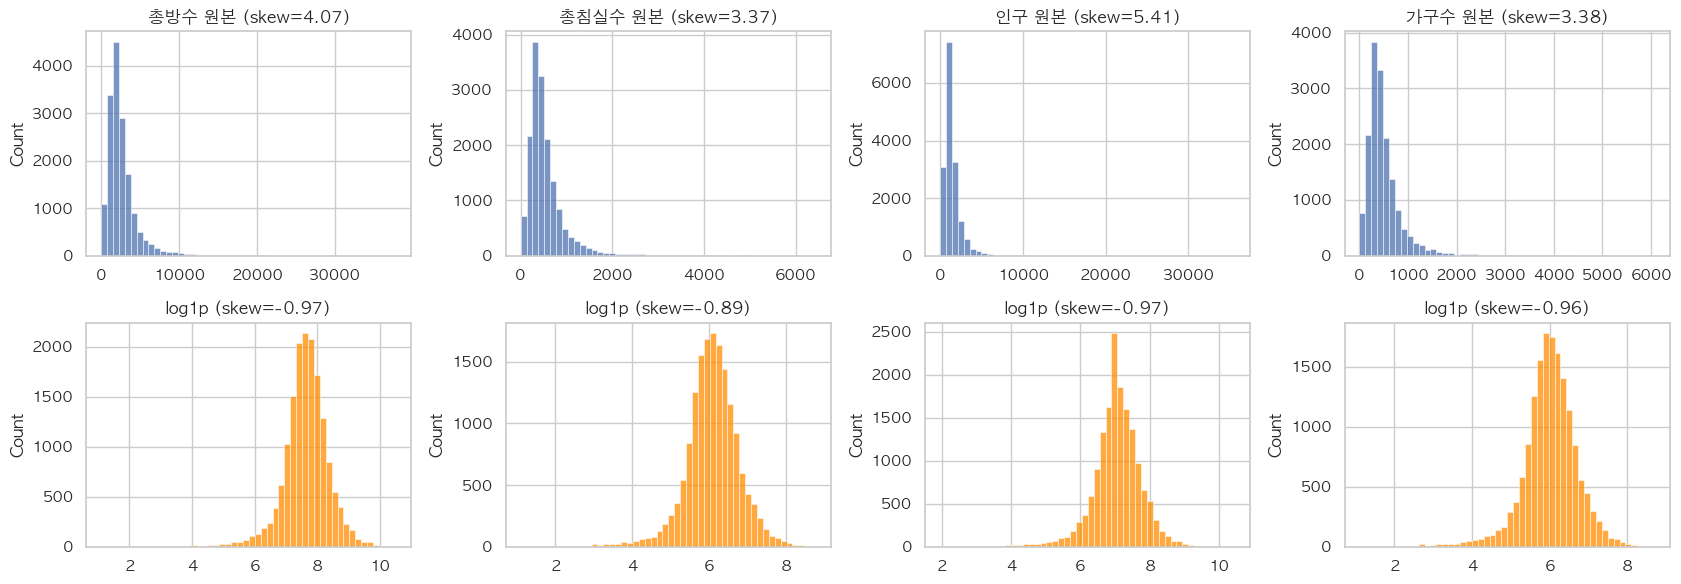

In [26]:
SKEWED = ["총방수", "총침실수", "인구", "가구수"]
fig, axes = plt.subplots(2, 4, figsize=(17, 6))
for i, col in enumerate(SKEWED):
  sns.histplot(housing[col], bins=50, ax=axes[0, i])
  axes[0, i].set_title(f"{col} 원본 (skew={housing[col].skew():.2f})")
  logged = np.log1p(housing[col])
  sns.histplot(logged, bins=50, ax=axes[1, i], color="darkorange")
  axes[1, i].set_title(f"log1p (skew={logged.skew():.2f})")
for ax in axes.ravel():
  ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [27]:
for col in SKEWED:
  housing[col] = np.log1p(housing[col])
housing[SKEWED].skew().round(2)

총방수    -0.97
총침실수   -0.89
인구     -0.97
가구수    -0.96
dtype: float64

---
## 6. 구간화와 인코딩

### 6.1 소득 구간: 층화 분할용

소득구간
1     642
2    5288
3    6019
4    2853
5    1384
Name: count, dtype: int64


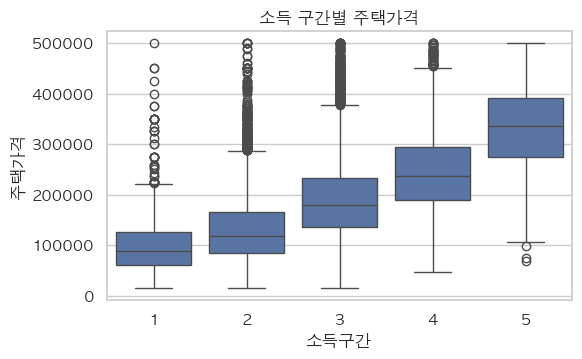

In [28]:
housing["소득구간"] = pd.cut(housing["소득중앙값"], bins=[0, 1.5, 3, 4.5, 6, np.inf], labels=[1, 2, 3, 4, 5])
print(housing["소득구간"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=housing, x="소득구간", y="주택가격", ax=ax)
ax.set_title("소득 구간별 주택가격")
plt.show()

### 6.2 권역: 범주형 만들고 원-핫 인코딩

위도 경계는 지도에서 대략 로스앤젤레스 권(34.5 미만), 중부, 샌프란시스코 권(37.5 이상)을 가르는 값입니다.

In [29]:
housing["권역"] = pd.cut(housing["위도"], bins=[0, 34.5, 37.5, 90], labels=["남부", "중부", "북부"])
print(housing.groupby("권역", observed=True)["주택가격"].agg(["count", "median"]))

    count     median
권역                  
남부   8538 187,500.00
중부   2761 140,400.00
북부   4887 152,700.00


In [30]:
housing = pd.get_dummies(housing, columns=["권역"], drop_first=True, dtype=int)
print([c for c in housing.columns if c.startswith("권역")], " <- 남부가 기준(둘 다 0)")

['권역_중부', '권역_북부']  <- 남부가 기준(둘 다 0)


---
## 7. 데이터 분할: 소득 구간으로 층화

회귀 문제는 `stratify=y` 를 쓸 수 없지만, **가장 중요한 입력 변수의 구간** 으로 층화하면 train/test 의 소득 분포를 똑같이 맞출 수 있습니다.

In [31]:
from sklearn.model_selection import train_test_split

X = housing.drop(columns=["주택가격"])
y = housing["주택가격"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X["소득구간"])
_, X_test_rand, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

pd.DataFrame({
  "전체": X["소득구간"].value_counts(normalize=True).sort_index(),
  "층화 test": X_test["소득구간"].value_counts(normalize=True).sort_index(),
  "무작위 test": X_test_rand["소득구간"].value_counts(normalize=True).sort_index(),
}).round(4)

,전체,층화 test,무작위 test
소득구간,,,
1,0.04,0.04,0.04
2,0.33,0.33,0.34
3,0.37,0.37,0.37
4,0.18,0.18,0.17
5,0.09,0.09,0.08


In [32]:
# 층화에만 쓴 소득구간은 이제 제거 (소득중앙값과 같은 정보)
X_train = X_train.drop(columns=["소득구간"])
X_test = X_test.drop(columns=["소득구간"])
print("train:", X_train.shape, "| test:", X_test.shape)
print("컬럼:", X_train.columns.tolist())

train: (12948, 13) | test: (3238, 13)
컬럼: ['경도', '위도', '주택연식', '총방수', '총침실수', '인구', '가구수', '소득중앙값', '가구당방수', '침실비율', '가구당인구', '권역_중부', '권역_북부']


---
## 8. 스케일링

원-핫 컬럼(0/1)은 제외하고 연속형만 `StandardScaler` 로 맞춥니다. **train 으로 fit, test 는 transform 만.**

In [33]:
from sklearn.preprocessing import StandardScaler

num_cols = [c for c in X_train.columns if not c.startswith("권역")]
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

X_train_s.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
경도,-0.00,1.00,-2.39,2.61
위도,-0.00,1.00,-1.45,2.93
주택연식,0.00,1.00,-2.21,1.92
총방수,-0.00,1.00,-6.92,3.92
총침실수,-0.00,1.00,-6.49,3.76
인구,0.00,1.00,-6.79,4.51
가구수,-0.00,1.00,-6.80,3.78
소득중앙값,0.00,1.00,-2.04,7.26
가구당방수,-0.00,1.00,-2.10,3.91
침실비율,-0.00,1.00,-1.66,3.76


---
## 9. 전처리 효과 확인: 전처리 전 vs 후

평가는 **RMSE**(평균적으로 몇 달러 틀리나, 작을수록 좋음)와 **R²**(평균만 찍을 때보다 오차를 몇 % 줄였나, 1 에 가까울수록 좋음)로 합니다. 자세한 설명은 5회차 2.3 절에 있습니다.

같은 `LinearRegression` 으로, 2장에서 만든 **결측 데이터를 최소한만 처리(결측 행 삭제)** 한 경우와 **오늘의 전처리** 를 비교합니다. 평가는 학습에 전혀 쓰지 않은 `california_housing_test.csv` 로 합니다.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def evaluate(model, X_eval, y_eval) -> dict:
  pred = model.predict(X_eval)
  return {"RMSE": int(np.sqrt(mean_squared_error(y_eval, pred))), "R2": round(r2_score(y_eval, pred), 4)}


# (A) 최소 처리: 결측 행 삭제만
raw = make_missing(housing_true, MISSING_RATIOS, seed=42).dropna()
lr_raw = LinearRegression().fit(raw.drop(columns=["주택가격"]), raw["주택가격"])

# (B) 오늘의 전처리
lr_pre = LinearRegression().fit(X_train_s, y_train)


def preprocess_eval(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
  '''별도 평가 파일을 학습 데이터와 똑같은 규칙으로 변환 (통계·경계·스케일러는 모두 학습 때 것)'''
  out = df[df["주택가격"] < 500001].copy()
  out = impute_housing(out, ref=housing_true)
  out = add_ratio_features(out)
  out = clip_features(out, CLIP_BOUNDS)
  for col in SKEWED:
    out[col] = np.log1p(out[col])
  out["권역"] = pd.cut(out["위도"], bins=[0, 34.5, 37.5, 90], labels=["남부", "중부", "북부"])
  out = pd.get_dummies(out, columns=["권역"], drop_first=True, dtype=int)
  X_out = out.reindex(columns=X_train.columns, fill_value=0)
  X_out[num_cols] = scaler.transform(X_out[num_cols])
  return X_out, out["주택가격"]


X_eval, y_eval = preprocess_eval(housing_test)
X_eval_raw = housing_test[housing_test["주택가격"] < 500001]

pd.DataFrame([
  {"방식": "(A) 결측 행 삭제만", **evaluate(lr_raw, X_eval_raw.drop(columns=["주택가격"]), X_eval_raw["주택가격"])},
  {"방식": "(B) 전처리 전체", **evaluate(lr_pre, X_eval, y_eval)},
]).set_index("방식")

,RMSE,R2
방식,,
(A) 결측 행 삭제만,62706,0.58
(B) 전처리 전체,59154,0.63


같은 모델인데 **입력만 바꿔서** 오차가 줄었습니다. 모델을 바꾸기 전에 데이터를 먼저 다듬어야 하는 이유입니다. (6회차의 트리 모델은 이상치·스케일에 덜 민감해서 이런 차이가 작아지는 경향이 있습니다.)

> (A) 와 (B) 의 평가 데이터는 모두 상한(500,001) 행을 뺀 같은 test 파일입니다. 공정한 비교를 위해 평가 대상을 맞췄습니다.

---
## 10. 저장

In [35]:
train_out = X_train_s.assign(주택가격=y_train.values)
test_out = X_test_s.assign(주택가격=y_test.values)
train_out.to_csv(f"{DATA_DIR}/housing_preprocessed_train.csv", index=False)
test_out.to_csv(f"{DATA_DIR}/housing_preprocessed_test.csv", index=False)
print("저장:", train_out.shape, test_out.shape)

저장: (12948, 14) (3238, 14)


#### 이 예제의 전처리 결정 요약

| 단계 | 결정 | 근거 (EDA) |
|------|------|------|
| 결측 | 총침실수 = 총방수 × 침실비율, 나머지 중앙값 | 상관 0.93, 치우친 분포 (3장 RMSE 비교) |
| 파생 | 가구당방수, 침실비율, 가구당인구 | 크기 변수끼리 상관 0.9 이상 |
| 이상치 | 주택가격 상한 행 제거, 비율 변수 1~99% clip | 500,001 쌓임, IQR 삭제 시 손실 큼 |
| 변환 | 크기 변수 4개 log1p | 왜도 3~5 |
| 구간화 | 소득구간(층화용), 권역(인코딩용) | 소득이 핵심 변수, 위치가 가격에 영향 |
| 인코딩 | 권역 원-핫 (drop_first) | 순서 없는 범주 |
| 분할 | 소득구간 층화 8:2 | 소득 분포를 train/test 에 동일하게 |
| 스케일링 | 연속형만 StandardScaler | 단위가 제각각 |

---
## 11. 실습 문제

원본 파일을 다시 읽어 시작합니다.

In [36]:
df = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
df = make_missing(df, {"총침실수": 0.05, "가구수": 0.05}, seed=7)
print(df.isnull().sum()[lambda s: s > 0])

총침실수    850
가구수     850
dtype: int64


### 문제 1. 관계 기반 대체

`가구수` 의 결측을 **`인구 / (인구/가구수 의 중앙값)`** 으로 채우시오. 그리고 `총침실수` 는 중앙값으로 채운 뒤 전체 결측 개수를 출력하시오.

In [37]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
persons_per_house = (df["인구"] / df["가구수"]).median()
df["가구수"] = df["가구수"].fillna(df["인구"] / persons_per_house)
df["총침실수"] = df["총침실수"].fillna(df["총침실수"].median())
print(df.isnull().sum().sum())
```

</details>

### 문제 2. 상한 행 제거와 로그 변환

`주택가격` 이 500,001 인 행을 제거하고 인덱스를 다시 매기시오. 그 다음 `인구` 에 `log1p` 를 적용한 `인구_log` 컬럼을 만들고, 변환 전후 왜도를 출력하시오.

In [38]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df = df[df["주택가격"] < 500001].reset_index(drop=True)
df["인구_log"] = np.log1p(df["인구"])
print(round(df["인구"].skew(), 2), "->", round(df["인구_log"].skew(), 2))
```

</details>

### 문제 3. 구간화 + 층화 분할

`주택연식` 을 `[0, 10, 20, 30, 40, 53]` 경계로 나눈 `연식구간` (라벨 1~5) 을 만들고, 이 구간으로 층화하여 `X_train, X_test, y_train, y_test` 로 7:3 분할하시오 (`random_state=0`, 목표 변수 `주택가격`, `연식구간` 은 X 에서 제외). train 과 test 의 `연식구간` 비율을 비교 출력하시오.

In [39]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["연식구간"] = pd.cut(df["주택연식"], bins=[0, 10, 20, 30, 40, 53], labels=[1, 2, 3, 4, 5])
X = df.drop(columns=["주택가격"])
y = df["주택가격"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=X["연식구간"])
print(pd.DataFrame({
  "train": X_train["연식구간"].value_counts(normalize=True).sort_index(),
  "test": X_test["연식구간"].value_counts(normalize=True).sort_index(),
}).round(3))
X_train = X_train.drop(columns=["연식구간"])
X_test = X_test.drop(columns=["연식구간"])
```

</details>

### 문제 4. 스케일링

문제 3 의 결과에 `MinMaxScaler` 를 적용하여 `X_train_scaled`, `X_test_scaled` (DataFrame, 컬럼명 유지) 를 만들고, `X_test_scaled` 의 최솟값·최댓값이 0~1 을 벗어나는 컬럼이 있는지 출력하시오. 벗어날 수 있는 이유를 한 줄로 적으시오.

In [40]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train_scaled = pd.DataFrame(mm.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(mm.transform(X_test), columns=X_test.columns, index=X_test.index)
out_of_range = X_test_scaled.columns[(X_test_scaled.min() < 0) | (X_test_scaled.max() > 1)].tolist()
print(out_of_range)
# 스케일러의 min/max 는 train 기준이므로, test 에 train 범위 밖의 값이 있으면 0~1 을 벗어난다 (정상)
```

</details>